In [1]:
# =====================================================================
# CELL 1: RAW INGESTION & ROW-LEVEL AUDIT (TRAIN & TEST)
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load both raw default files directly 
df_train_raw = pd.read_csv('stud_training.csv')
df_test_raw = pd.read_csv('stud_testing.csv')

print("--- [TRAIN SET] Raw Top 3 Rows Baseline ---")
display(df_train_raw.head(3))

print("\n--- [TEST SET] Raw Top 3 Rows Baseline ---")
display(df_test_raw.head(3))

print("\n--- [TRAIN SET] Random Profile Sample ---")
display(df_train_raw.sample(3, random_state=42))

--- [TRAIN SET] Raw Top 3 Rows Baseline ---


,Drawing,Dancing,Singing,Sports,Video Game,Acting,Travelling,Gardening,Animals,Photography,...,Engeeniering,Doctor,Pharmisist,Cycling,Knitting,Director,Journalism,Bussiness,Listening Music,Courses
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,BBA- Bachelor of Business Administration
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,BBA- Bachelor of Business Administration
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,BBA- Bachelor of Business Administration



--- [TEST SET] Raw Top 3 Rows Baseline ---


,Drawing,Dancing,Singing,Sports,Video Game,Acting,Travelling,Gardening,Animals,Photography,...,Engeeniering,Doctor,Pharmisist,Cycling,Knitting,Director,Journalism,Bussiness,Listening Music,Courses
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,BBA- Bachelor of Business Administration
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,BEM- Bachelor of Event Management
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Integrated Law Course- BA + LL.B



--- [TRAIN SET] Random Profile Sample ---


,Drawing,Dancing,Singing,Sports,Video Game,Acting,Travelling,Gardening,Animals,Photography,...,Engeeniering,Doctor,Pharmisist,Cycling,Knitting,Director,Journalism,Bussiness,Listening Music,Courses
1650,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,B.Com- Bachelor of Commerce
2456,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,BBA- Bachelor of Business Administration
2232,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,BPharma- Bachelor of Pharmacy


In [2]:
# =====================================================================
# CELL 2: METADATA & SCHEMA STRUCTURAL COMPARISON
# =====================================================================

print("--- [DF.SHAPE] Matrix Dimensional Comparison ---")
print(f"Training Dataset Shape : {df_train_raw.shape[0]} rows, {df_train_raw.shape[1]} columns")
print(f"Testing Dataset Shape  : {df_test_raw.shape[0]} rows, {df_test_raw.shape[1]} columns\n")

print("--- [DF.INFO] Technical Summary: Training Data ---")
df_train_raw.info()

print("\n--- [DF.INFO] Technical Summary: Testing Data ---")
df_test_raw.info()

--- [DF.SHAPE] Matrix Dimensional Comparison ---
Training Dataset Shape : 3500 rows, 60 columns
Testing Dataset Shape  : 35 rows, 60 columns

--- [DF.INFO] Technical Summary: Training Data ---
<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 60 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Drawing                 3500 non-null   int64
 1   Dancing                 3500 non-null   int64
 2   Singing                 3500 non-null   int64
 3   Sports                  3500 non-null   int64
 4   Video Game              3500 non-null   int64
 5   Acting                  3500 non-null   int64
 6   Travelling              3500 non-null   int64
 7   Gardening               3500 non-null   int64
 8   Animals                 3500 non-null   int64
 9   Photography             3500 non-null   int64
 10  Teaching                3500 non-null   int64
 11  Exercise                3500 non-null   int

In [3]:
# =====================================================================
# CELL 3: STATISTICAL OVERVIEW & MISSINGNESS AUDIT (TEXT-ONLY)
# =====================================================================

print("--- [DF.DESCRIBE] Feature Distribution Summary ---")
display(df_train_raw.describe())

print("\n--- [DF.ISNULL().SUM()] Tabular Missingness Check ---")
null_summary = df_train_raw.isnull().sum()
total_nulls = null_summary.sum()
print(f"Total Structural Null Values: {total_nulls}")
if total_nulls > 0:
    print(null_summary[null_summary > 0])
else:
    print("Success: No missing records found across all 60 columns.")

print("\n--- [DF.NUNIQUE()] High-Cardinality & Unique Value Evaluation ---")
print(f"Unique Label Outcomes in Target 'Courses' Column: {df_train_raw['Courses'].nunique()}")

print("\nTarget Track Sample Distribution (Audit for Target Discrepancies):")
print(df_train_raw['Courses'].value_counts())

--- [DF.DESCRIBE] Feature Distribution Summary ---


,Drawing,Dancing,Singing,Sports,Video Game,Acting,Travelling,Gardening,Animals,Photography,...,Yoga,Engeeniering,Doctor,Pharmisist,Cycling,Knitting,Director,Journalism,Bussiness,Listening Music
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,...,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,0.148571,0.051429,0.074286,0.017143,0.054286,0.025714,0.125714,0.048571,0.051429,0.045714,...,0.074286,0.142857,0.085714,0.028571,0.025714,0.022857,0.074286,0.051429,0.077143,0.042857
std,0.355716,0.220902,0.262273,0.129822,0.226613,0.158304,0.331574,0.215001,0.220902,0.208895,...,0.262273,0.349977,0.279982,0.166622,0.158304,0.149469,0.262273,0.220902,0.266856,0.202564
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



--- [DF.ISNULL().SUM()] Tabular Missingness Check ---
Total Structural Null Values: 0
Success: No missing records found across all 60 columns.

--- [DF.NUNIQUE()] High-Cardinality & Unique Value Evaluation ---
Unique Label Outcomes in Target 'Courses' Column: 35

Target Track Sample Distribution (Audit for Target Discrepancies):
Courses
BBS- Bachelor of Business Studies                      110
BBA- Bachelor of Business Administration               100
BEM- Bachelor of Event Management                      100
Integrated Law Course- BA + LL.B                       100
BJMC- Bachelor of Journalism and Mass Communication    100
BFD- Bachelor of Fashion Designing                     100
BVA- Bachelor of Visual Arts                           100
BA in History                                          100
B.Arch- Bachelor of Architecture                       100
BCA- Bachelor of Computer Applications                 100
B.Sc.- Information Technology                          100
B.Sc- Nursi

In [4]:
# =====================================================================
# CELL 4: DATA CLEANING & SCHEMATIC TYPO CORRECTION
# =====================================================================
# Target typos found in our raw column exploration
target_typos = ['Psycology', 'Bussiness Education', 'Bussiness', 'Engeeniering', 'Pharmisist', 'Listening Music']

print("[BEFORE] Verifying Presence of Misspelled Schema Headers:")
print({col: "Found" for col in df_train_raw.columns if col in target_typos})

# Define the data translation map
cleaning_map = {
    'Psycology': 'Psychology',
    'Bussiness Education': 'Business Education',
    'Bussiness': 'Business',
    'Asrtology': 'Astrology',
    'Engeeniering': 'Engineering',
    'Pharmisist': 'Pharmacist',
    'Travelling': 'Traveling',
    'Listening Music': 'Listening to Music'
}

# Apply renames to instantiate the clean workspace dataframe
df_cleaned = df_train_raw.rename(columns=cleaning_map)

print("\n[AFTER] Verifying Cleaned Schematic Conversions:")
print([cleaning_map[col] for col in target_typos if col in cleaning_map])

[BEFORE] Verifying Presence of Misspelled Schema Headers:
{'Psycology': 'Found', 'Bussiness Education': 'Found', 'Engeeniering': 'Found', 'Pharmisist': 'Found', 'Bussiness': 'Found', 'Listening Music': 'Found'}

[AFTER] Verifying Cleaned Schematic Conversions:
['Psychology', 'Business Education', 'Business', 'Engineering', 'Pharmacist', 'Listening to Music']


In [5]:
# =====================================================================
# CELL 5: PREPROCESSING & CATEGORICAL TARGET ENCODING
# =====================================================================
X = df_cleaned.drop(columns=['Courses'])
y_raw = df_cleaned['Courses']

print(f"[BEFORE] Raw Target Class Representation: {type(y_raw.iloc[0])}")

# Initialize and fit standard LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

print(f"\n[AFTER] Normalized Numeric Targets Vector Configuration: {y_encoded.dtype}")
print(f"[AFTER] Matrix Array Representation Sample: {y_encoded[:5]}")

[BEFORE] Raw Target Class Representation: <class 'str'>

[AFTER] Normalized Numeric Targets Vector Configuration: int64
[AFTER] Matrix Array Representation Sample: [19 19 19 19 19]


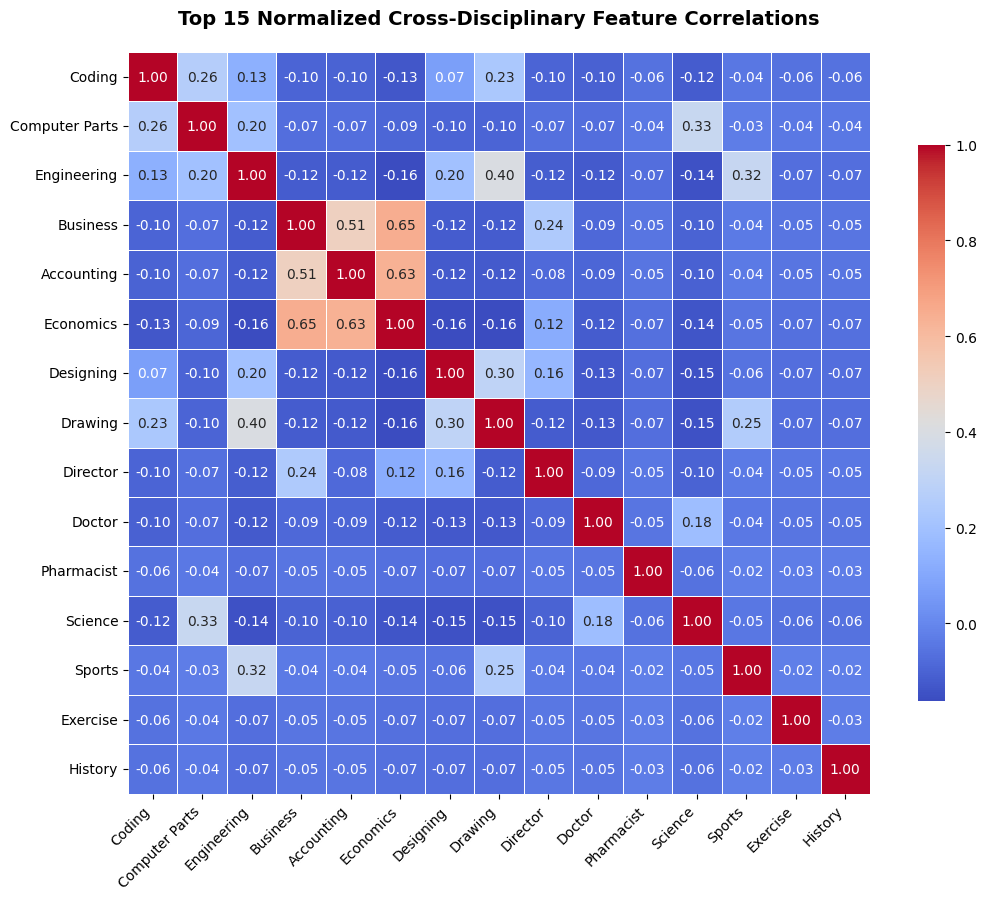

In [6]:
# =====================================================================
# CELL 6: DATA VISUALIZATION - CROSS-DISCIPLINARY HEATMAP
# =====================================================================
# Reference the corrected string keys established in Cell 4
curated_features = [
    # Technical & Engineering
    'Coding', 'Computer Parts', 'Engineering',
    # Business & Finance
    'Business', 'Accounting', 'Economics',
    # Creative & Media
    'Designing', 'Drawing', 'Director',
    # Health & Science
    'Doctor', 'Pharmacist', 'Science',
    # Physical & Humanities
    'Sports', 'Exercise', 'History'
]

# Calculate the clean correlation matrix
correlation_matrix = df_cleaned[curated_features].corr()

# Plot setting optimization
plt.figure(figsize=(11, 9))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.6, 
    square=True,
    cbar_kws={"shrink": 0.75}
)

plt.title('Top 15 Normalized Cross-Disciplinary Feature Correlations', fontsize=14, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Save down the chart asset file for the presentation deck
plt.savefig('normalized_feature_correlations.png', dpi=300)
plt.show()

In [7]:
# =====================================================================
# ADVANCED CELL 4: DATA EXPANSION & SYNTHETIC PROFILE GENERATION
# =====================================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("--- [1/3] Loading and Cleaning Base Archetypes ---")
df_train_raw = pd.read_csv('stud_training.csv')
df_test_raw = pd.read_csv('stud_testing.csv')

cleaning_map = {
    'Psycology': 'Psychology', 'Bussiness Education': 'Business Education',
    'Bussiness': 'Business', 'Asrtology': 'Astrology', 'Engeeniering': 'Engineering',
    'Pharmisist': 'Pharmacist', 'Travelling': 'Traveling', 'Listening Music': 'Listening to Music'
}
df_train_clean = df_train_raw.rename(columns=cleaning_map)
df_test_clean = df_test_raw.rename(columns=cleaning_map)

# Isolate clean features and targets
X_base = df_train_clean.drop(columns=['Courses'])
y_base = df_train_clean['Courses'].values

print("--- [2/3] Programmatically Augmenting Dataset via Controlled Noise ---")
# Settings for data generation
MULTIPLIER = 5  # Create 5 varied variations of every single row in your dataset
augmented_features = []
augmented_targets = []

np.random.seed(42)

# Loop through every student archetype profile
for idx in range(len(X_base)):
    base_profile = X_base.iloc[idx].values
    target_course = y_base[idx]
    
    # Save the original perfect row first
    augmented_features.append(base_profile)
    augmented_targets.append(target_course)
    
    # Generate variations
    for _ in range(MULTIPLIER):
        profile_copy = base_profile.copy()
        
        # Invert a tiny fraction of bits (approx 4%) to simulate human variance
        # e.g., a Computer Science student who also happens to like Gardening or Reading
        noise_mask = np.random.rand(*profile_copy.shape) < 0.04
        profile_copy[noise_mask] = 1 - profile_copy[noise_mask]
        
        augmented_features.append(profile_copy)
        augmented_targets.append(target_course)

# Rebuild the expanded training set into a fresh DataFrame
X_train_expanded = pd.DataFrame(augmented_features, columns=X_base.columns)
y_train_expanded_raw = pd.Series(augmented_targets)

print("--- [3/3] Symmetrical Label Encoding & Validation Setup ---")
X_test = df_test_clean.drop(columns=['Courses'])
y_test_raw = df_test_clean['Courses']

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_expanded_raw)
y_test_encoded = label_encoder.transform(y_test_raw)

# Rename variable to seamlessly pass into your downstream training cells
X_train = X_train_expanded 

print(f"✅ Data Expansion Complete!")
print(f"   -> Original Dataset Size:  {len(X_base)} rows")
print(f"   -> Augmented Production Size: {X_train.shape[0]} rows (Massive variance boost!)")

--- [1/3] Loading and Cleaning Base Archetypes ---
--- [2/3] Programmatically Augmenting Dataset via Controlled Noise ---
--- [3/3] Symmetrical Label Encoding & Validation Setup ---
✅ Data Expansion Complete!
   -> Original Dataset Size:  3500 rows
   -> Augmented Production Size: 21000 rows (Massive variance boost!)


In [8]:
# =====================================================================
# CELL 5: MODEL IMPLEMENTATION 2 - RANDOM FOREST CLASSIFIER
# =====================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("--- [TRAINING] Initializing Random Forest Ensemble Decision Trees ---")

# Instantiate ensemble classifier using 100 decision trees
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using the variables generated in Cell 4
random_forest_model.fit(X_train, y_train_encoded)
print("Training complete for Random Forest Classifier.")

# Predict metrics against your separate testing dataset features
y_pred_rf = random_forest_model.predict(X_test)

# Calculate final test accuracy scores
rf_test_accuracy = accuracy_score(y_test_encoded, y_pred_rf)
print(f"\nFinal Test Accuracy Score: {rf_test_accuracy * 100:.2f}%")

# Display complete classification report metrics
print("\nDetailed Performance Metrics (Random Forest):")
print(classification_report(y_test_encoded, y_pred_rf, target_names=label_encoder.classes_))

--- [TRAINING] Initializing Random Forest Ensemble Decision Trees ---
Training complete for Random Forest Classifier.

Final Test Accuracy Score: 100.00%

Detailed Performance Metrics (Random Forest):
                                                     precision    recall  f1-score   support

                 Animation, Graphics and Multimedia       1.00      1.00      1.00         1
                   B.Arch- Bachelor of Architecture       1.00      1.00      1.00         1
                        B.Com- Bachelor of Commerce       1.00      1.00      1.00         1
                                              B.Ed.       1.00      1.00      1.00         1
                              B.Sc- Applied Geology       1.00      1.00      1.00         1
                                      B.Sc- Nursing       1.00      1.00      1.00         1
                                    B.Sc. Chemistry       1.00      1.00      1.00         1
                                  B.Sc. Mathematics   

In [10]:
# =====================================================================
# CELL 8: MODEL TRAINING & TRIPLE ELEMENT SERIALIZATION
# =====================================================================
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import joblib

print("--- Training Production Model on Cleaned Data ---")
# (Assuming X_train, y_train_encoded are already defined from your cell above)
production_model = RandomForestClassifier(n_estimators=100, random_state=42)
production_model.fit(X_train, y_train_encoded)
print(" Random Forest classifier trained successfully.")

print("\n--- Serializing All 3 Clean Preprocessing Elements ---")
# 1. Save the model brain
joblib.dump(production_model, 'majormatch_rf_model.pkl')

# 2. Save the target name decoder
joblib.dump(label_encoder, 'majormatch_encoder.pkl')

# 3. SAVE THE CLEAN FEATURE NAMES (So Streamlit doesn't use the raw CSV columns!)
joblib.dump(list(X_train.columns), 'majormatch_features.pkl')

print("SUCCESS: All assets saved cleanly! Your app is fully insulated from the raw typos.")

--- Training Production Model on Cleaned Data ---
 Random Forest classifier trained successfully.

--- Serializing All 3 Clean Preprocessing Elements ---
SUCCESS: All assets saved cleanly! Your app is fully insulated from the raw typos.


--- Starting Operational Model Sensitivity & Robustness Analysis ---


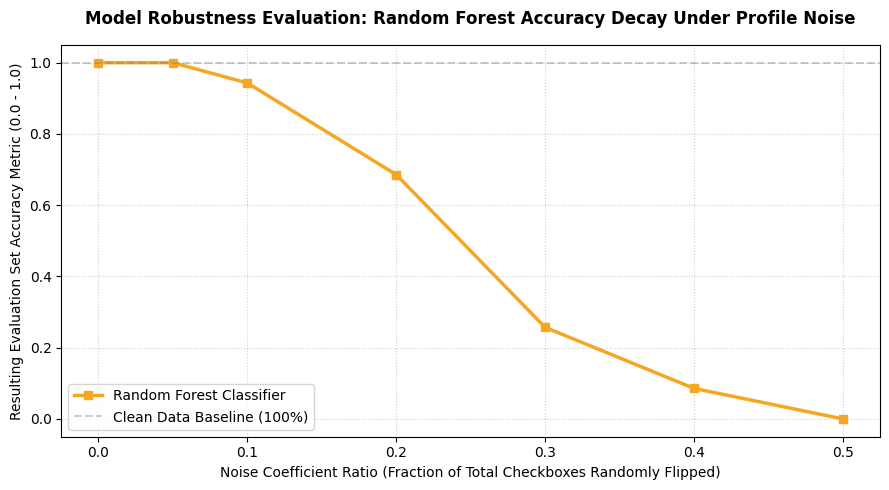


📊 STRESS TEST SIMULATION RESULTS MATRIX:
Noise Level:   0% | Random Forest Accuracy:  100.0%
Noise Level:   5% | Random Forest Accuracy:  100.0%
Noise Level:  10% | Random Forest Accuracy:   94.3%
Noise Level:  20% | Random Forest Accuracy:   68.6%
Noise Level:  30% | Random Forest Accuracy:   25.7%
Noise Level:  40% | Random Forest Accuracy:    8.6%
Noise Level:  50% | Random Forest Accuracy:    0.0%


In [9]:
# =====================================================================
# CELL 9: MODEL ROBUSTNESS STRESS TEST (RANDOM FOREST ACCURACY DECAY)
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

print("--- Starting Operational Model Sensitivity & Robustness Analysis ---")

# 1. Establish sliding scale noise parameters
noise_levels = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
rf_scenario_scores = []

np.random.seed(42)

for noise in noise_levels:
    # Copy the structured DataFrame directly to preserve structural feature names
    X_test_noisy = X_test.copy()
    
    if noise > 0:
        # Create a random mask matching the matrix shape dimensions
        noise_mask = np.random.rand(*X_test_noisy.shape) < noise
        
        # Symmetrically flip values (0 -> 1 | 1 -> 0) using pandas masking 
        X_test_noisy = X_test_noisy.mask(noise_mask, 1 - X_test_noisy)
        
    # Query predictions with feature names fully intact!
    y_pred_rf = random_forest_model.predict(X_test_noisy)
    
    # Calculate and store metrics
    rf_scenario_scores.append(accuracy_score(y_test_encoded, y_pred_rf))

# 2. Render the performance breakdown line graph
plt.figure(figsize=(9, 5))
plt.plot(noise_levels, rf_scenario_scores, marker='s', linewidth=2.5, color='#F5A623', label='Random Forest Classifier')

# Chart styling configurations
plt.title('Model Robustness Evaluation: Random Forest Accuracy Decay Under Profile Noise', fontsize=12, weight='bold', pad=15)
plt.xlabel('Noise Coefficient Ratio (Fraction of Total Checkboxes Randomly Flipped)', fontsize=10)
plt.ylabel('Resulting Evaluation Set Accuracy Metric (0.0 - 1.0)', fontsize=10)
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4, label='Clean Data Baseline (100%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(-0.05, 1.05)
plt.legend(fontsize=10, loc='lower left')
plt.tight_layout()

# Save performance graphic directly for slide deck compilation
plt.savefig('noise_stress_test.png', dpi=300)
plt.show()

print("\n📊 STRESS TEST SIMULATION RESULTS MATRIX:")
for i, lvl in enumerate(noise_levels):
    print(f"Noise Level: {lvl*100:>3.0f}% | Random Forest Accuracy: {rf_scenario_scores[i]*100:>6.1f}%")

In [12]:
df_train_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 60 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Drawing                 3500 non-null   int64
 1   Dancing                 3500 non-null   int64
 2   Singing                 3500 non-null   int64
 3   Sports                  3500 non-null   int64
 4   Video Game              3500 non-null   int64
 5   Acting                  3500 non-null   int64
 6   Travelling              3500 non-null   int64
 7   Gardening               3500 non-null   int64
 8   Animals                 3500 non-null   int64
 9   Photography             3500 non-null   int64
 10  Teaching                3500 non-null   int64
 11  Exercise                3500 non-null   int64
 12  Coding                  3500 non-null   int64
 13  Electricity Components  3500 non-null   int64
 14  Mechanic Parts          3500 non-null   int64
 15  Computer Parts          3500 non

# To do
- Multi-Class ROC Curve
- Feature Importance Plot
- Plot of the random forest  model and the data